In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision.models import resnet18
import torchvision.transforms as transforms

from membership_dataset import MembershipDataset

In [2]:
# config
BASE = Path().resolve()
# BASE = Path(__file__).parent
PUB_PATH = BASE / "pub.pt"
PRIV_PATH = BASE / "priv.pt"
MODEL_PATH = BASE / "model.pt"
OUTPUT_CSV = BASE / "submission.csv"

In [3]:
model = resnet18(weights=None)
model.conv1 = torch.nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)  # small images
model.maxpool = torch.nn.Identity()   # remove maxpool
model.fc = torch.nn.Linear(512, 9)   # 9 classes
model.load_state_dict(torch.load("model.pt", map_location="cpu"))
model.eval()                          # critical for inference

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [4]:
MEAN = [0.7406, 0.5331, 0.7059]   # per-channel mean used during training
STD = [0.1491, 0.1864, 0.1301]    # per-channel std used during training

transform = transforms.Compose([
    transforms.Resize(32),                     # resize to match training resolution
    transforms.Normalize(mean=MEAN, std=STD),  # (pixel - mean) / std per channel
])

In [5]:
pub_ds = torch.load(PUB_PATH, weights_only=False)
priv_ds = torch.load(PRIV_PATH, weights_only=False)

pub_ds.transform = transform    # attach normalization after loading
priv_ds.transform = transform

loader = DataLoader(pub_ds, batch_size=64, shuffle=False)
# loader = DataLoader(priv_ds, batch_size=64, shuffle=False)

In [6]:
criterion = torch.nn.CrossEntropyLoss(reduction="none")  # one loss value per sample

In [7]:
# uncomment to run for all values of the dataset and see the predicted labels and confidence scores

all_ids = []
all_scores = []
all_labels = []
all_memberships = []
all_preds = []

with torch.no_grad():
    for id_, imgs, labels, membership in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        logits = model(imgs)
        loss = criterion(logits, labels).cpu().numpy()
        scores = -loss      # negate: lower loss = more member-like

        all_ids.extend(id_.tolist())
        all_scores.extend(scores.tolist())
        all_memberships.extend(membership.tolist())

In [8]:
df = pd.DataFrame({
    "id": all_ids,
    "membership": all_memberships,
    "score": all_scores,
})

df

,id,membership,score
0,72212,1,-0.063750
1,21370,0,-0.042587
2,52004,1,-0.059046
3,29848,0,-0.057081
4,45154,0,-0.047116
...,...,...,...
13995,42581,0,-0.060977
13996,12732,0,-0.046779
13997,41211,1,-0.047911
13998,16842,0,-0.037273


In [9]:
df.to_csv("negative_loss_pub_data.csv", index=False)

In [10]:
df = pd.read_csv("negative_loss_pub_data.csv")
df

,id,membership,score
0,72212,1,-0.063750
1,21370,0,-0.042587
2,52004,1,-0.059046
3,29848,0,-0.057081
4,45154,0,-0.047116
...,...,...,...
13995,42581,0,-0.060977
13996,12732,0,-0.046779
13997,41211,1,-0.047911
13998,16842,0,-0.037273


In [11]:
df["score"].describe()

count    14000.000000
mean        -0.069907
std          0.219963
min         -5.518887
25%         -0.055245
50%         -0.047825
75%         -0.040801
max         -0.009479
Name: score, dtype: float64

In [12]:
df[df["membership"] == 0].describe()

,id,membership,score
count,7000.000000,7000.0,7000.000000
mean,53892.868286,0.0,-0.080968
std,30953.694957,0.0,0.281004
min,0.000000,0.0,-5.518887
25%,27270.750000,0.0,-0.055295
50%,53846.500000,0.0,-0.047853
75%,80699.000000,0.0,-0.040838
max,107153.000000,0.0,-0.010346


In [13]:
df[df["membership"] == 1].describe()

,id,membership,score
count,7000.000000,7000.0,7000.000000
mean,53223.669286,1.0,-0.058846
std,31085.083470,0.0,0.132539
min,4.000000,1.0,-4.554924
25%,26123.250000,1.0,-0.055149
50%,53687.000000,1.0,-0.047793
75%,79974.750000,1.0,-0.040749
max,107176.000000,1.0,-0.009479


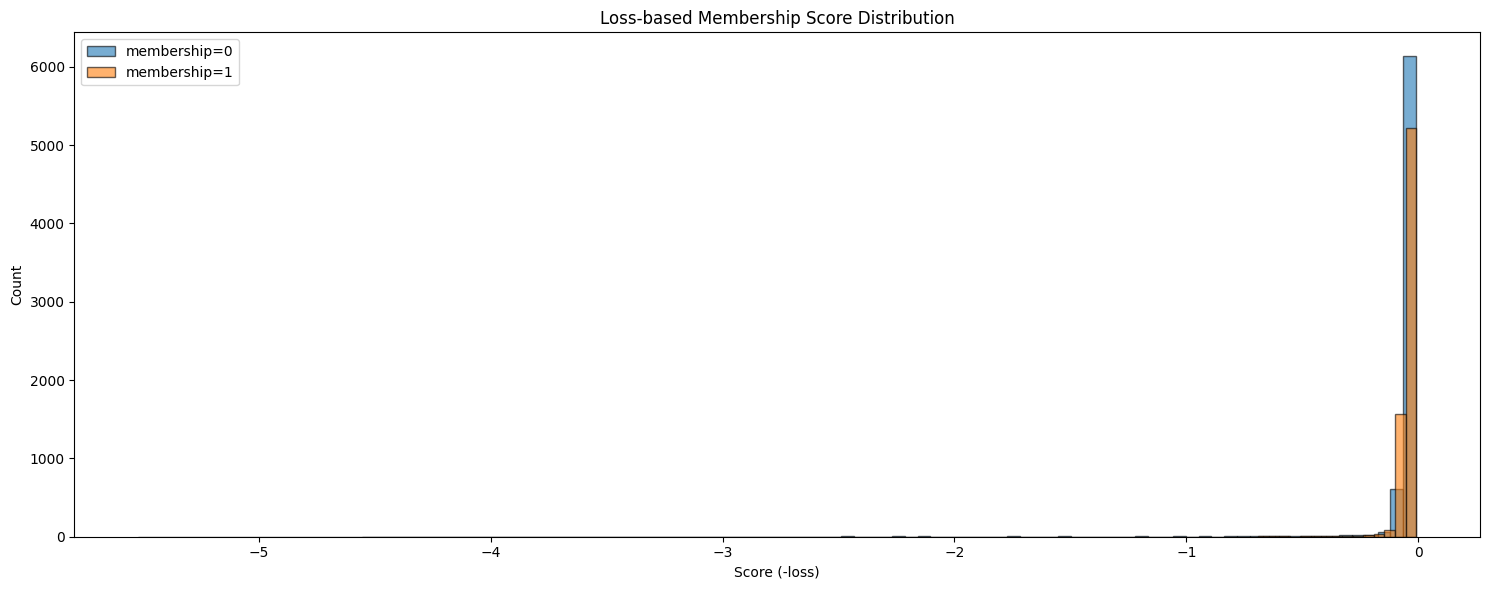

In [23]:
plt.figure(figsize=(15, 6))
for m, group in df.groupby("membership"):
    plt.hist(group["score"], bins=100, alpha=0.6, label=f"membership={m}", edgecolor="black")
plt.xlabel("Score (-loss)")
plt.ylabel("Count")
plt.title("Loss-based Membership Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
# removing higher values
test_df = df[df["score"] >= -0.2]
test_df

,id,membership,score
0,72212,1,-0.063750
1,21370,0,-0.042587
2,52004,1,-0.059046
3,29848,0,-0.057081
4,45154,0,-0.047116
...,...,...,...
13995,42581,0,-0.060977
13996,12732,0,-0.046779
13997,41211,1,-0.047911
13998,16842,0,-0.037273


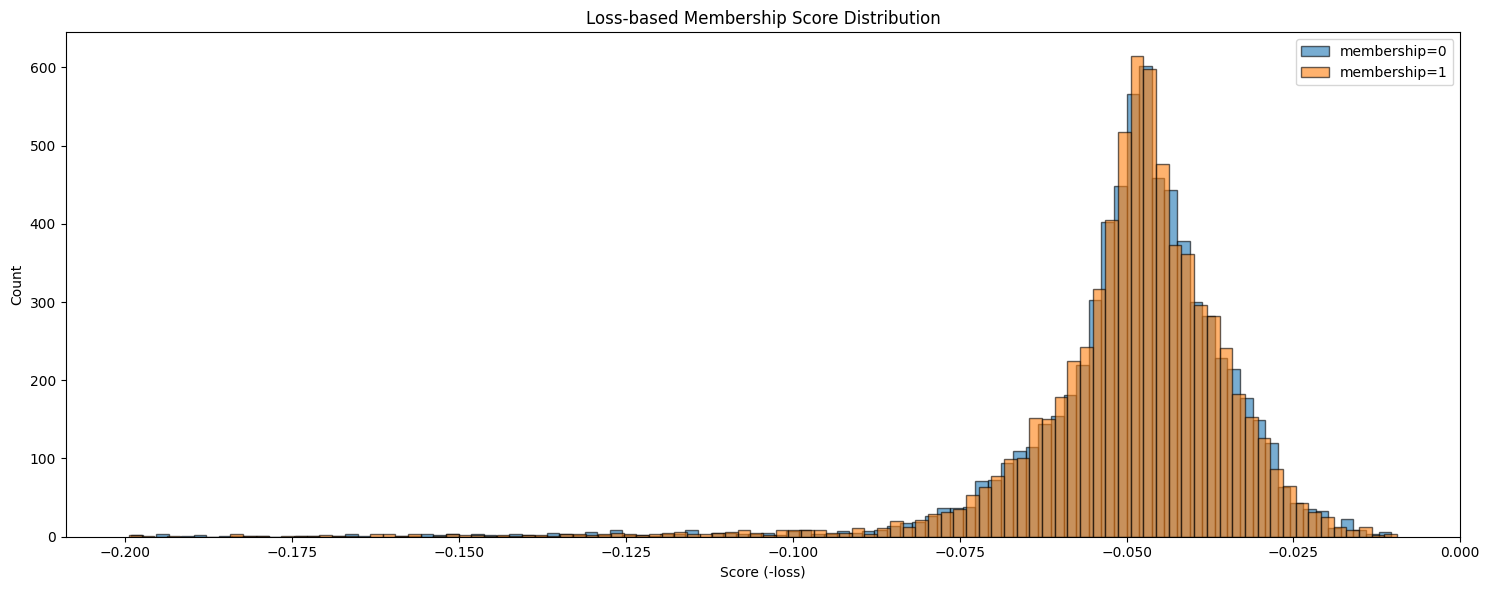

In [37]:
plt.figure(figsize=(15, 6))
for m, group in test_df.groupby("membership"):
    plt.hist(group["score"], bins=100, alpha=0.6, label=f"membership={m}", edgecolor="black")
plt.xlabel("Score (-loss)")
plt.ylabel("Count")
plt.title("Loss-based Membership Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# OBSERVATION:
# As we are using -loss as the score, right side of the graph should be more likely members. 
# There is no clear distinction between the loss values for both classes

# The loss based strategy does not seem to work well as both members and non-members have similar 
# loss value distributions. It makes sense because the model's confidence scores were very high 
# and followed similar distributions for both cases so obviously loss also reflects that